In [121]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from typing import Iterable, List, Tuple, Optional, Sequence, Union
from scipy.ndimage import gaussian_filter1d
from utils import load_data, get_one_index
from matplotlib.colors import LinearSegmentedColormap

In [122]:
def plot_neuron_sorted_heatmaps(
    file_path: str,
    ana_tt: Iterable[str],
    ana_bt: Iterable[str],
):
    data = load_data(file_path)

    condition_list = [(tt, bt) for tt in ana_tt for bt in ana_bt]

    mats = []
    for rule_name, behavior_name in condition_list:
        tt_id, bt_id = get_one_index(rule_name, behavior_name)
        fr = data["firing"][tt_id][bt_id] # shape (n_neurons, n_trials, n_positions)
        fr_mean = np.mean(fr, axis=1) # shape (n_neurons, n_positions)
        mats.append(fr_mean)

    sort_mat = mats[0]
    peak_pos = np.nanargmax(sort_mat, axis=1)
    peak_val = np.nanmax(sort_mat, axis=1)
    sort_order = np.lexsort((peak_val, peak_pos))
    
    n_panels = len(condition_list)
    figsize = (3.0 * n_panels, 7.0)

    fig, axes = plt.subplots(1, n_panels, figsize=figsize, squeeze=False)
    axes = axes[0]

    ims = []
    sorted_mats = {}
    
    zones = data["zones"]
    # cmap = LinearSegmentedColormap.from_list(
    #     "blue_to_yellow", [(0, "blue"), (1, "yellow")]
    # )
    palette = ["#351988", "#048498" ,"#f9f662"]
    custom_cmap = LinearSegmentedColormap.from_list("custom_blue_yellow", palette, N=256)

    for id, ax in enumerate(axes):
        cond = condition_list[id]
        mat = mats[id][sort_order, :]
        sorted_mats[cond] = mat

        im = ax.imshow(
            mat,
            aspect="auto",
            interpolation="nearest",
            origin="upper",
            cmap=custom_cmap,
            vmin=0.01,
            vmax=0.99,
        )
        ims.append(im)
        
        for zone in zones:
            ax.axvline(zone[0], color="red", lw=1.5)
            ax.axvline(zone[1], color="red", lw=1.5)

        rule_name, behavior_name = cond
        ax.set_title(rule_name, fontsize=18)

        ax.set_xlabel("Position", fontsize=18)
        ax.set_ylabel("Neuron (sorted)", fontsize=18)
        ax.tick_params(axis='both', labelsize=16)
        

    # fig.colorbar(ims[-1], ax=axes, shrink=0.8)

    plt.tight_layout()
    fig.show()

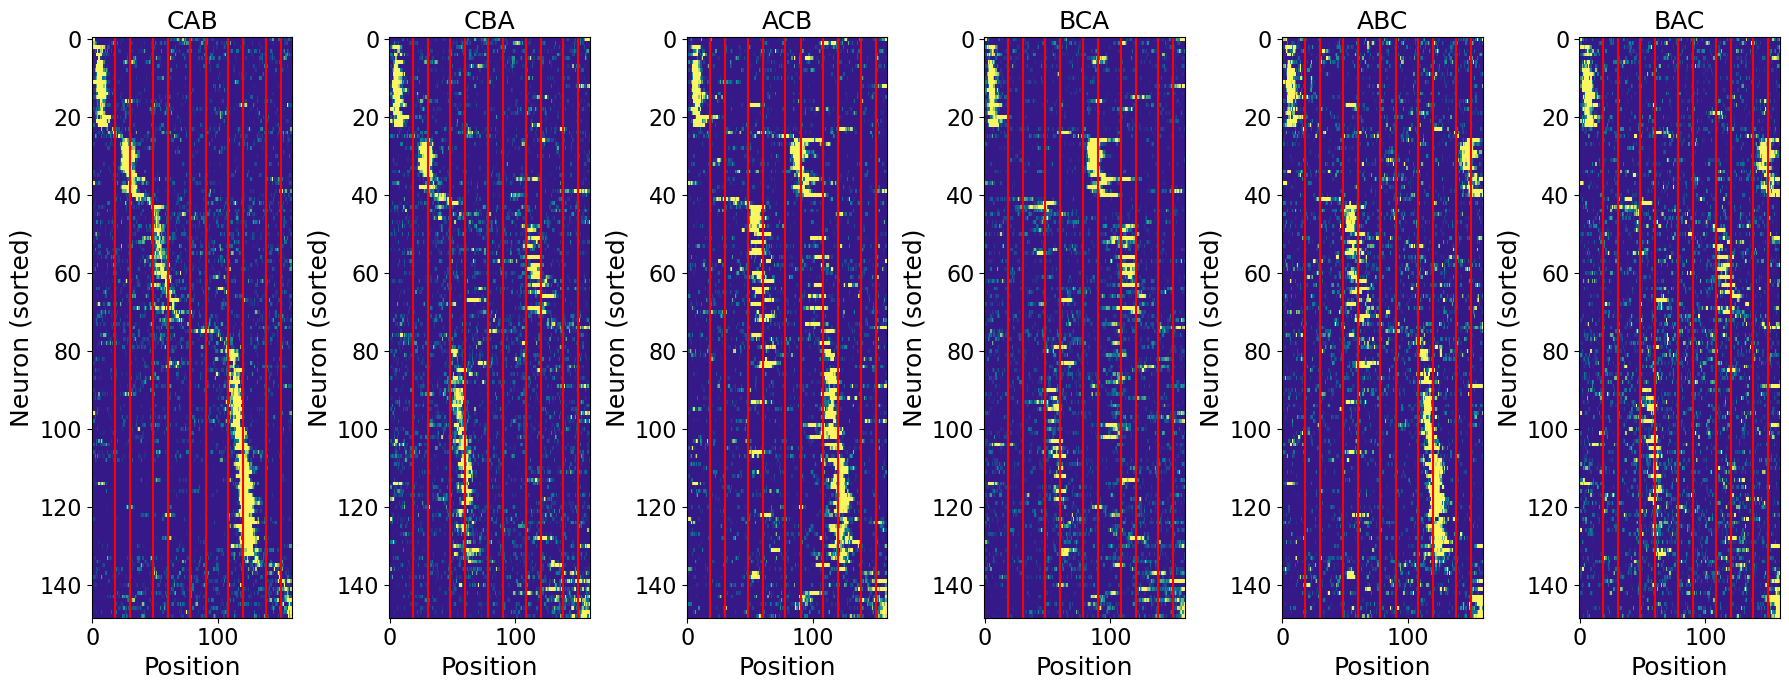

In [123]:
plot_neuron_sorted_heatmaps(
    file_path="../../data/HPC_2p/HP07/neuro_type_saveHP07_15_2025-03-08.mat",
    ana_tt=["CAB", "CBA", "ACB", "BCA", "ABC", "BAC"],
    ana_bt=["Correct"],
)

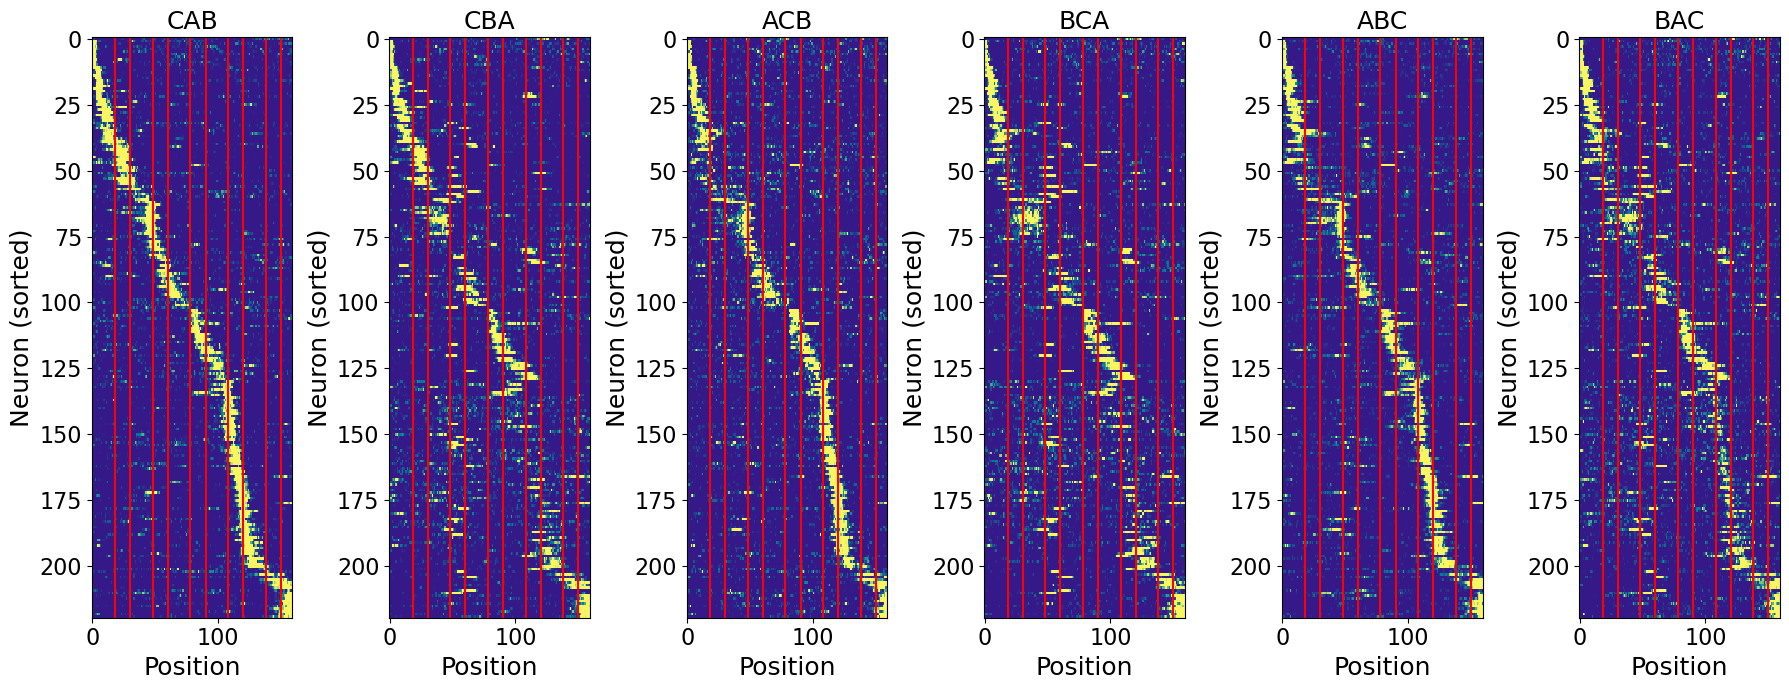

In [124]:
plot_neuron_sorted_heatmaps(
    file_path="../../data/HPC_2p/HP07/neuro_type_saveHP07_17_2025-03-11.mat",
    ana_tt=["CAB", "CBA", "ACB", "BCA", "ABC", "BAC"],
    ana_bt=["Correct"],
)